# Group Members:
Srimann Nambakkam sn29939,
Amaan Desai ad55777,
Walton Truelove wjt582

## Part 2.1 System Introduction:

The Stiff Scalar ODE that we chose for part 2 of our project is a mechanical system with high damping. The ODE itself is dx/dt = -(k/c)x + (1/c)F(t). X represents the physical extension of the system, with an initial value of 1 meter, and t represents time elapsed in seconds. k/c represents the damping rate of the system, which is essentially how quickly the system goes from the initial condition towards zero in the transient period. For our project, damping rate is equal to 5000 s^-1, which is very high. F(t) is set to equal 10sin(t), which represents a slow external force on the system which causes small oscillations after the transient period. Rewritten in standard form, this system becomes dx/dt = -5000x + 0.002sin(t). This system in particular has a number of practical applications. It can be used to model shock absorbers such as car suspensions, vibration dampers for heavy machinery, and seismic isolation in buildings and other structures, among other things. We also decided to do a timescale from 0 to 10 seconds. This might seems somewhat short but the fast transient for this system resolves incredibly quickly, so most of the time interval will be the slow dynamic period, giving us a wide range to evaluate its behavior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Problem parameters
lam = 5000.0  # Stiffness parameter
# Define the ODE: dx/dt = f(t, x), mechanical system with high damping
def f(t, x):    
    return -lam * x + 0.002 * np.sin(t)
def x_exact(t): # Analytical solution for dx/dt = -lam*x + g(t); x(t) = e^(-lam*t)*x0 + the integral from 0 to t of ((e^(-lam(t-s)))g(s)ds)
    return 1.0*np.exp(-5000*t) + 4e-7 * np.sin(t)

## Part: 2.2 Demonstrating Stiffness:

### Euler Forward Test:

In [2]:
def euler_forward(f, x0, t0, t_final, h):
    # Euler's Forward: x_{n+1} = x_n + h * f(t_n, x_n)
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)
    t[0] = t0
    x[0] = x0
    # Time stepping
    for n in range(num_steps):
        x[n+1] = x[n] + h * f(t[n], x[n])
        t[n+1] = t[n] + h
    return t, x

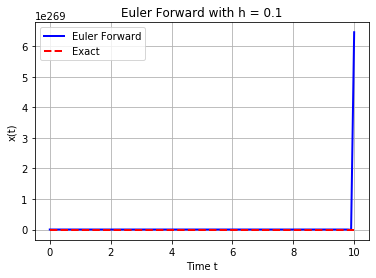

Maximum value reached: 6.46e+269
Solution blew up!


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


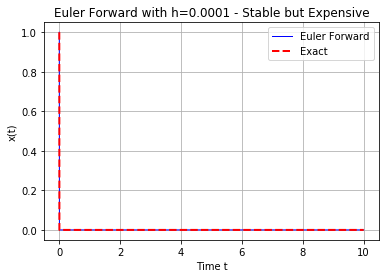

Number of steps needed: 100001
Maximum error: 1.18e-01


In [3]:
# Initial conditions
x0 = 1.0
t0 = 0.0
t_final = 10.0

# Trying Euler's Forward with h = 0.1
h_forward = 0.1
t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward)
# Plot
plt.figure()
plt.plot(t_forward, x_forward, 'b-', label='Euler Forward', linewidth=2)
plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Euler Forward with h = {h_forward}')
plt.legend()
plt.grid(True)
plt.show()
print(f"Maximum value reached: {np.max(np.abs(x_forward)):.2e}")
print("Solution blew up!")

# Trying with very small step size h = 0.0001
h_small = 0.0001
t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_small)
plt.figure()
plt.plot(t_forward, x_forward, 'b-', label='Euler Forward', linewidth=1)
plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Euler Forward with h={h_small} - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()
print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(x_forward - x_exact(t_forward))):.2e}")

### Calculating Stiffness Ratio:

In [4]:
# Stiffness ratio calculation
t_fast = lam # Fastest time scale from lambda = 5000
t_slow = 1 # slowest time scale from sin(t) term
print(f"Stiffness Ratio for the System: {t_fast/t_slow} (Very Stiff!)")

Stiffness Ratio for the System: 5000.0 (Very Stiff!)


### Demonstration of Impracticality of Explicit Methods:

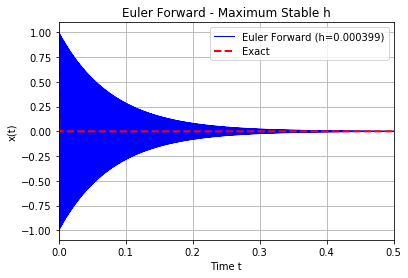

Number of steps needed: 25063
Maximum error: 1.13e+00


In [5]:
# Maximum stable step size calculation and steps needed
h_stable = 0.000399 # h < 2/|lam| for Euler's Forward Stability; 2/|lam| = 0.0004, so stable h is ~0.000399...
t_stable, x_stable = euler_forward(f, x0, t0, t_final, h_stable)

plt.figure()
plt.plot(t_stable, x_stable, 'b-', label=f'Euler Forward (h={h_stable})', linewidth=1)
plt.plot(t_stable, x_exact(t_stable), 'r--', label='Exact', linewidth=2)
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.xlim(0.0, 0.5)
plt.title('Euler Forward - Maximum Stable h')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_stable)}")
print(f"Maximum error: {np.max(np.abs(x_stable - x_exact(t_stable))):.2e}")

### Phase Plot:

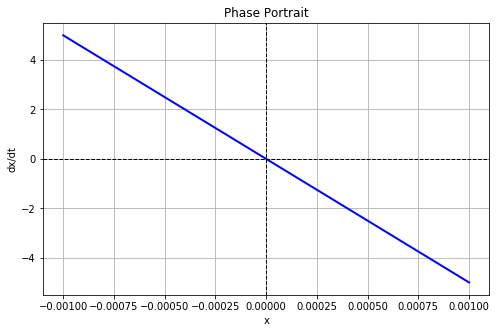

In [28]:
'''
Plotting x vs. dx/dt; honestly not entirely sure how this is meant to be interpreted but our takeaway is that
this shows that the system rapidly approaches equilibrium due to the large lambda term, which indicates its 
stiffness
'''
x_vals = np.linspace(-0.001, 0.001, 1000)

dxdt = -5000 * x_vals + 0.002 * np.sin(0)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, dxdt, 'b-', linewidth=2)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.title('Phase Portrait')
plt.grid(True)
plt.show()

When initially testing with an already fairly small step size of h=0.1, Euler's forward blows up. Further testing with an even smaller value of h=0.0001 reaches stability, but at an extremely high computational cost of 100001 steps for a time interval from 0 to 10 seconds. This happens because this is a stiff system. The very high lambda value of -5000 followed by a slowly varying sine function results in a very fast transient period where x falls from 1 nearly to zero almost instantaneously, followed by a very small sine wave. This abrupt change is very hard for Euler's forward to handle, meaning an extremely small step size is necessary for a stable solution. The stiffness ratio was then calculated to be 5000, further indicating a very stiff system. Additionally, the largest stable value of h for Euler's Forward is defined by the inequality h < 2/lambda. This was used to find that h must be less than 0.0004 in order to produce a stable solution for this system. Even then, with an h value of 0.00399, Euler's Forward still handles the transient part poorly, with a maximum error greater than 1, the initial condition of the system, despite eventually approaching stability for the dynamic part, and over 25000 steps necessary to reach a solution. As such, implicit methods will likely be far more effective for this system.

## Part 2.3 Backward Euler with Newton-Raphson Implementation:

### Defining the Residual Function and Derivative:

In [7]:
def residual(x_next, x_n, t_next, h):
    """
    Residual function for implicit Euler.
    We want to solve: x_{n+1} = x_n + h * f(t_{n+1}, x_{n+1})
    Rearrange: g(x_{n+1}) = x_{n+1} - x_n - h*f(t_{n+1}, x_{n+1}) = 0
    Returns: residual g(x_{n+1})
    """
    return x_next - x_n - h * f(t_next, x_next)
# Test the residual
t_test = 1.0
h_test = 0.1
x_n_test = x_exact(t_test)
x_next_test = x_exact(t_test + h_test)

g_test = residual(x_next_test, x_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")

Residual when using exact solution: 1.99e-08
(Should be very close to zero)


In [8]:
def residual_derivative(h):
    """
    Derivative of residual with respect to x_{n+1}.
    For our problem: f(t,x) = -lambda*y + g(t)
    So: df/dy = -lambda
    Therefore: g'(x_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h
    Returns: g'(x_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy
# Verify numerically with finite differences
def residual_derivative_numerical(x_next, x_n, t_next, h, eps=1e-8):
    return (residual(x_next + eps, x_n, t_next, h) - 
            residual(x_next - eps, x_n, t_next, h)) / (2 * eps)
# Test at a random point
x_test = 0.5
g_prime_analytical = residual_derivative(h_test)
g_prime_numerical = residual_derivative_numerical(x_test, x_n_test, t_test, h_test)

print(f"Analytical g': {g_prime_analytical:.6f}")
print(f"Numerical g':  {g_prime_numerical:.6f}")
print(f"Difference:    {abs(g_prime_analytical - g_prime_numerical):.2e}")

Analytical g': 501.000000
Numerical g':  501.000001
Difference:    9.52e-07


### Defining Newton-Raphson:

In [9]:
def newton_raphson_step(x_n, t_next, h, tol=1e-8, max_iter=20, verbose=True):
    """
    Solve for x_{n+1} using Newton-Raphson iteration.
    We want to find x_{n+1} such that g(x_{n+1}) = 0
    Newton-Raphson: x^(k+1) = x^(k) - g(x^(k)) / g'(x^(k))
    Returns: (x_{n+1}, number of iterations)
    Verbose Condition used for testing, will be set to false when used in the backward Euler function
    """
    # Initial guess: use explicit Euler as predictor
    x_guess = x_n + h * f(t_next - h, x_n)  

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: x = {x_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(x_guess, x_n, t_next, h)

        if verbose:
            print(f"  Iteration {k}: x = {x_guess:.6f}, g = {g:.2e}")
                   
        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"Converged in {k} iteration(s)!\n")
            return x_guess, k
        
        # Newton-Raphson update     
        delta = -g / g_prime
        x_guess = x_guess + delta
        
    # Did not converge
    print(f"Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return x_guess, max_iter

# Test Newton-Raphson on one step
x_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

x_next, iters = newton_raphson_step(x_n, t_n + h, h, verbose=True)

print(f"Result: x({t_n + h}) = {x_next:.6f}")
print(f"Exact:  x({t_n + h}) = {x_exact(t_n + h):.6f}")
print(f"Error:  {abs(x_next - x_exact(t_n + h)):.2e}")


  Starting Newton-Raphson at t = 0.1000
  Initial guess: x = -499.000000
  g'(constant) = 501.000000

  Iteration 0: x = -499.000000, g = -2.50e+05
  Iteration 1: x = 0.001996, g = -6.24e-12
Converged in 1 iteration(s)!

Result: x(0.1) = 0.001996
Exact:  x(0.1) = 0.000000
Error:  2.00e-03


Our Newton-Raphson function works, converging with minimal error

### Euler's Backward Implementation:

In [10]:
def euler_backward(f, x0, t0, t_final, h, tol=1e-8, verbose=True):
    """
    For each time step:
    1. Solve x_{n+1} = x_n + h*f(t_{n+1}, x_{n+1}) using Newton-Raphson
    2. Move to next time step
    Returns:
    - t: array of time points
    - x: array of solution values
    - iterations: array of NR iterations per step
    Modular in that f, x0, t0, t_final, and h can be changed to solve any stiff system 
    with varying parameters and step sizes
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    x[0] = x0

    # Time stepping loop
    for n in range(num_steps):
        # Solve for x_{n+1} using Newton-Raphson
        x[n+1], iterations[n] = newton_raphson_step(x[n], t[n] + h, h, tol=tol, verbose=False)
        t[n+1] = t[n] + h
        
    if(verbose==True): #For monitoring NR Convergence behavior
        print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
        print(f"  Max NR iterations: {np.max(iterations)}")
        print(f"  Min NR iterations: {np.min(iterations)}\n")
    return t, x, iterations

Test 1 h = 0.1
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



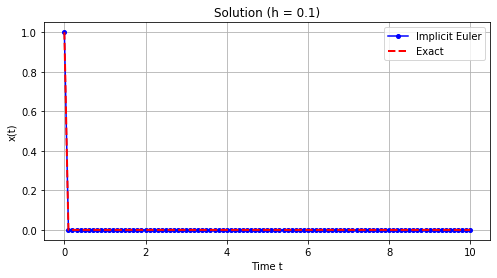

Number of steps: 101

Test 2 h = 0.5
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



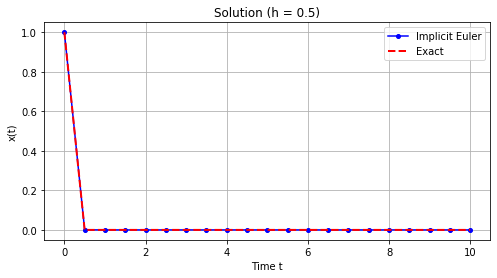

Number of steps: 21

Test 3 h = 1.0
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



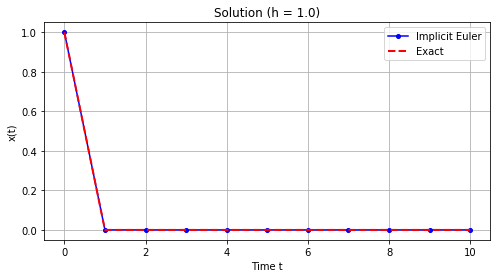

Number of steps: 11

Test 4 h = 1.5
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



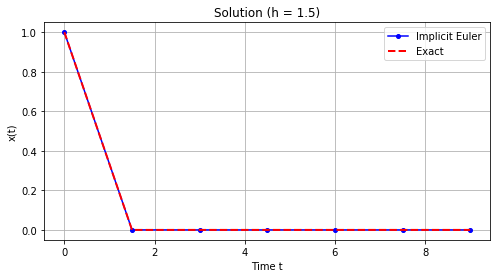

Number of steps: 7



In [11]:
# Test and plot with different h values

test_hs = [0.1, 0.5, 1.0, 1.5]
for n, h in enumerate(test_hs):
    print(f"Test {n+1} h = {h}")
    t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h, verbose=True)
    plt.figure(figsize=(8, 4))
    plt.plot(t_backward, x_backward, 'b-o', markersize=4, label='Implicit Euler')
    plt.plot(t_backward, x_exact(t_backward), 'r--', linewidth=2, label='Exact')
    plt.xlabel('Time t')
    plt.ylabel('x(t)')
    plt.title(f'Solution (h = {h})')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"Number of steps: {len(t_backward)}")
    print("")

Euler's Backward with Newton-Raphson was able to produce a stable solution even with higher step sizes. Additionally, Newton-Raphson itself converged in one iteration for all tested step sizes due to the ODE's linear nature.

## Part 2.4 Stability Analysis and Comparison:

### Step Size Comparison Table:

In [12]:
# Fixed reference grid for more accurate max error
t_ref = np.linspace(t0, t_final, 10000)
x_ref = x_exact(t_ref)
h_stable_forward = 0.000399   # = ~0.000399  (stability limit: |1 + h*(-λ)| < 1)
table_configs = [
    ("Euler Forward (stable)", h_stable_forward, "forward"),
    ("Euler Forward (unstable)", 0.001,            "forward"),
    ("Euler Backward h=0.001",   0.001,  "backward"),
    ("Euler Backward h=0.1",     0.1,    "backward"),
    ("Euler Backward h=0.5",     0.5,    "backward"),
    ("Euler Backward h=1.0",     1.0,    "backward"),
    ("Euler Backward h=1.5",     1.5,    "backward")]
print("Step Size Comparison Table")
print(f"{'Method':<30} {'~h':>8}  {'Steps':>7}  {'Stable?':>8}  {'Max Error':>12}")
print("-" * 65)
for label, h, method in table_configs:
    num_steps = int((t_final - t0) / h)
    if method == "forward":
        t_s, x_s = euler_forward(f, x0, t0, t_final, h)
        stable = np.all(np.isfinite(x_s)) and np.max(np.abs(x_s)) < 1e10
        if stable:
            x_interp = np.interp(t_ref, t_s, x_s)
            err = np.max(np.abs(x_interp - x_ref)) 
        else:
            err = float('inf')
    else:
        t_s, x_s, _ = euler_backward(f, x0, t0, t_final, h, verbose=False)
        stable = True
        x_interp = np.interp(t_ref, t_s, x_s)
        err = np.max(np.abs(x_interp - x_ref))
    print(f"{label:<30} {h:>8.4f}  {num_steps:>7d}  {'YES' if stable else 'NO':>8}  {err:>12.3e}")
print("-" * 65)
print(f"\nEuler Forward stability limit:  h < 2/λ ==> h < 2/{lam:.0f} ==> h < {2/lam:.2e}")
print(f"Euler Backward stability limit: All h > 0")

Step Size Comparison Table
Method                               ~h    Steps   Stable?     Max Error
-----------------------------------------------------------------
Euler Forward (stable)           0.0004    25062       YES     9.499e-01
Euler Forward (unstable)         0.0010    10000        NO           inf
Euler Backward h=0.001           0.0010    10000       YES     1.599e-01
Euler Backward h=0.1             0.1000      100       YES     9.833e-01
Euler Backward h=0.5             0.5000       20       YES     9.960e-01
Euler Backward h=1.0             1.0000       10       YES     9.980e-01
Euler Backward h=1.5             1.5000        6       YES     9.986e-01
-----------------------------------------------------------------

Euler Forward stability limit:  h < 2/λ ==> h < 2/5000 ==> h < 4.00e-04
Euler Backward stability limit: All h > 0


<ipython-input-1-dae23b2c300b>:7: RuntimeWarning: overflow encountered in double_scalars
  return -lam * x + 0.002 * np.sin(t)
<ipython-input-2-c9e1e9284149>:11: RuntimeWarning: invalid value encountered in double_scalars
  x[n+1] = x[n] + h * f(t[n], x[n])


### Computational Cost Comparison:

In [13]:
t_ref = np.linspace(t0, t_final, 10000)
x_ref = x_exact(t_ref)

h_values_back = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 1.5]

print("Accuracy vs. Computational Cost for Euler's Backward")
print("-"*75)
print(f"{'h':>6}  {'Steps':>6}  {'Avg NR iters':>13}  {'Total f evals':>14}  {'Max Error':>12}")

backward_results = {}
for h in h_values_back:
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    num_steps = len(t_b) - 1
    avg_iters = np.mean(iters_b)
    total_f = int(np.sum(iters_b)) + num_steps
    mask = (t_ref >= t_b[0]) & (t_ref <= t_b[-1])
    x_interp = np.interp(t_ref[mask], t_b, x_b)
    max_err = np.max(np.abs(x_interp - x_ref[mask]))
    backward_results[h] = dict(steps=num_steps, avg_iters=avg_iters, total_f=total_f,
                                err=max_err, t=t_b, x=x_b, iters=iters_b)
    print(f"{h:>6.3f}  {num_steps:>6d}  {avg_iters:>13.2f}  {total_f:>14d}  {max_err:>12.3e}")

# Euler Forward comparison row
t_fwd, x_fwd = euler_forward(f, x0, t0, t_final, h_stable_forward)
steps_fwd = len(t_fwd) - 1
total_f_fwd = steps_fwd
mask = (t_ref >= t_fwd[0]) & (t_ref <= t_fwd[-1])
x_interp_fwd = np.interp(t_ref[mask], t_fwd, x_fwd)
err_fwd = np.max(np.abs(x_interp_fwd - x_ref[mask]))
print("-" * 75)
print("Euler Forward with largest stable h:")
print(f"{h_stable_forward:>6}  {steps_fwd:>6d}  {'N/A':>13}  {total_f_fwd:>14d}  {err_fwd:>12.3e}")

Accuracy vs. Computational Cost for Euler's Backward
---------------------------------------------------------------------------
     h   Steps   Avg NR iters   Total f evals     Max Error
 0.001   10000           0.44           14369     1.599e-01
 0.010    1000           0.50            1499     8.952e-01
 0.050     200           0.98             396     9.733e-01
 0.100     100           1.00             200     9.833e-01
 0.500      20           1.00              40     9.960e-01
 1.000      10           1.00              20     9.980e-01
 1.500       6           1.00              12     9.986e-01
---------------------------------------------------------------------------
Euler Forward with largest stable h:
0.000399   25062            N/A           25062     9.499e-01


### Overall Performance Analysis:

As shown by both tables, Euler's Backward is able to remain stable with much higher step size values than Euler's Forward. Additionally Euler's Backward is able to have a fairly small maximum error, with this value for all step sizes being nearly equivalent to the maximum error for the largest stable h for Euler's Forward. Additionally, Euler's Backward is significantly less costly computationally at all step sizes compared to a stable Forward Euler, with a minimal increase in error. As such, it makes significantly more sense to use Euler's Backward for this problem as it is much computationally cheaper and does not sacrifice a significant amount of accuracy compared to Euler's Forward. Ultimately, I would recommend a step size of around 0.1 for this particular problem. It ensures a small error while also being relatively computationally cheap across the interval, and it can still effectively model the very small oscillations present in the dynamic portion while accounting for the fast transient.

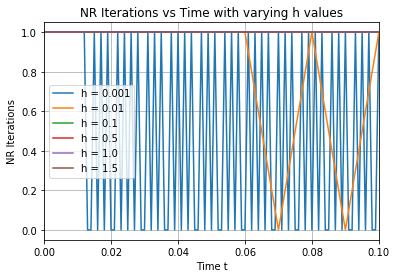

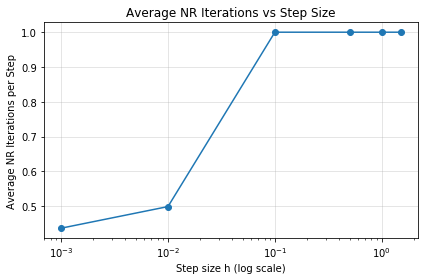

In [14]:
# NR Iterations vs Time Plot
test_hs = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5]
plt.figure()
for h in (test_hs):
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    plt.plot(t_b[:-1], iters_b, label=f'h = {h}')
plt.xlabel('Time t'); plt.ylabel('NR Iterations')
plt.xlim(0.0, 0.1) # Limited time range to better illustrate the rapid oscillation between 1 and 0 iterations for small h
plt.title('NR Iterations vs Time with varying h values')
plt.legend()
plt.grid(True)
plt.show()
# Average NR Iterations vs Step Size
avg_iters = []
for h in test_hs:
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    avg_iters.append(np.mean(iters_b))

plt.figure()
plt.semilogx(test_hs, avg_iters, 'o-')
plt.xlabel('Step size h (log scale)')
plt.ylabel('Average NR Iterations per Step')
plt.title('Average NR Iterations vs Step Size')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

As step size increases, Newton-Raphson tends to take one iteration to converge. Interestingly, with smaller step sizes, it occasionally takes 0 iterations to converge. This is because the slow dynamic part is such a small sine wave that the initial guess is within the set tolerance. Additionally, the number of iterations for convergence never really goes beyond 1 because the system is linear.

### Solution Quality:

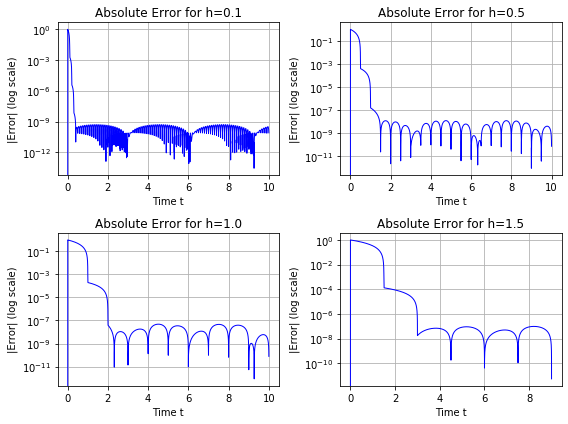

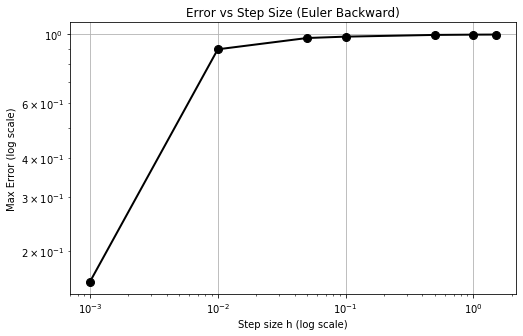

In [15]:
# Error Plotting
t_ref = np.linspace(t0, t_final, 10000)
x_ref = x_exact(t_ref)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

error_hs = [0.1, 0.5, 1.0, 1.5]
for n, h in enumerate(error_hs):
    t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h, verbose=False)
    mask = (t_ref >= t_backward[0]) & (t_ref <= t_backward[-1])
    x_interp = np.interp(t_ref[mask], t_backward, x_backward)
    error = np.abs(x_interp - x_ref[mask])
    axes[n].semilogy(t_ref[mask], error, 'b-', linewidth=1)
    axes[n].set_xlabel('Time t')
    axes[n].set_ylabel('|Error| (log scale)')
    axes[n].set_title(f'Absolute Error for h={h}')
    axes[n].grid(True)
plt.tight_layout()
plt.show()

# Error vs Step Size Plot; uses data from computational cost table
h_vals = sorted(backward_results.keys())
max_errors = [backward_results[h]['err'] for h in h_vals]

plt.figure(figsize=(8, 5))
plt.loglog(h_vals, max_errors, 'ko-', markersize=8, linewidth=2)
plt.xlabel('Step size h (log scale)')
plt.ylabel('Max Error (log scale)')
plt.title('Error vs Step Size (Euler Backward)')
plt.grid(True)
plt.show()

As step size increases, both absolute and maximum error increase. Additionally, absolute error at any given point never exceeds 1 for any of the tested step sizes, indicating a very high quality solution that works with a variety of step sizes.

In [16]:
# Verification that Solution remains within bounds
print("Verifying Solutions remain within Reasonable Physical Bounds...")
h = 0.1
t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h, verbose=False)
if np.min(x_backward)<-1 or np.max(x_backward)>1: # While system could oscillate below zero, it should not shoot off towards negative infinity, nor should it exceed the initial value of x=1
    print("Error: Euler's Backward Solution does not remain within reasonable physical bounds!")
else:
    print("Euler's Backward Solution remains within reasonable physical bounds!")
x_analytical = x_exact(t_backward)
if np.min(x_analytical)<-1 or np.max(x_analytical)>1: # While system could oscillate below zero, it should not shoot off towards negative infinity, nor should it exceed the initial value of x=1
    print("Error: Analytical Solution does not remain within reasonable physical bounds!")
else:
    print("Analytical Solution remains within reasonable physical bounds!")

Verifying Solutions remain within Reasonable Physical Bounds...
Euler's Backward Solution remains within reasonable physical bounds!
Analytical Solution remains within reasonable physical bounds!


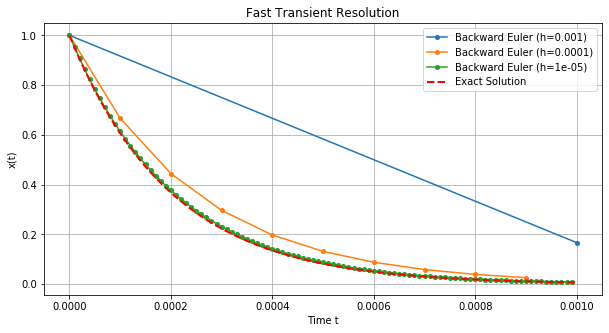

In [17]:
# Checking that fast transients are resolved correctly
transient_hs = [0.001, 0.0001, 0.00001] # Testing very small hs so there will be multiple points on the transient interval
t_dense = np.linspace(0, 0.001, 500)
plt.figure(figsize=(10, 5))
for h in transient_hs:
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    transient = t_b <= 0.001
    plt.plot(t_b[transient], x_b[transient], '-o', markersize=4, label=f'Backward Euler (h={h})')
plt.plot(t_dense, x_exact(t_dense), 'r--', linewidth=2, label='Exact Solution')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Fast Transient Resolution')
plt.legend()
plt.grid(True)
plt.show()

Backward Euler is capable of handling the fast transient portion very well, with small step sizes even capable of matching the curve almost exactly. Larger step sizes were not used for this specific plot however, as a stepsize of greater than ~0.001 extends beyond the fast transient portion, which would make it very small and difficult to visualize on a graph. Larger step sizes are still able to handle it however, as demonstrated by the small max errors from the error plotting. In fact, the largest individual max errors are caused by the step size simply exceeding the length of time in which the fast transient period occurs.

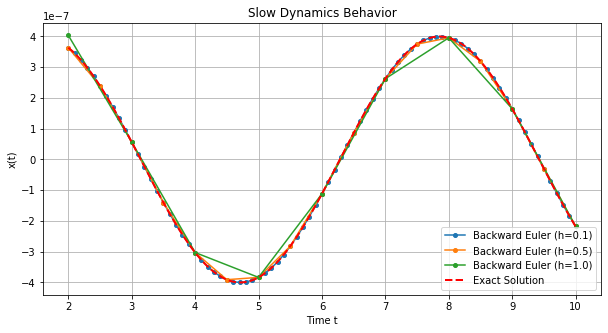

In [18]:
# Checking slow dynamics
t_dense = np.linspace(2.0, t_final, 2000) # Starting interval at t=2 to account for larger step sizes resolution of the fast transient
slow_hs = [0.1, 0.5, 1.0] # Large hs to show that they can handle the slow dynamic portion
plt.figure(figsize=(10,5))
for h in slow_hs:
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    slow = t_b >= 2.0
    plt.plot(t_b[slow], x_b[slow], '-o', markersize=4, label=f'Backward Euler (h={h})')
plt.plot(t_dense, x_exact(t_dense), 'r--', linewidth=2, label='Exact Solution')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Slow Dynamics Behavior')
plt.legend()
plt.grid(True)
plt.show()

## Part 2.5 Conclusion:

In completing Part 2 of the Final Project, we found several key insights. Perhaps the broadest and most important of these is that implicit methods such as Euler's Backward are far more effective at solving stiff systems than explicit methods such as Euler's Forward. Because of the combination of two vastly different time scales, Forward Euler's struggles significantly with a stiff problem, needing a very small step size to remain stable, while Euler's Backward does not. This is very valuable as the implementation of an implicit solver allows for the preservation of significant computational resources without sacrificing a large amount of accuracy, making it far more efficient than an explicit counterpart. A number of challenges were encountered along the way, such as determining how to accurately determine error given the fact that the Euler's Backward function creates different time intervals based on h, and coming up with the syntax for a table was somewhat challenging. Both of these were ultimately solvable however, by interpolating the Euler's Backward and analytical solutions along a set time interval, and taking significant inspiration from the live lecture, respectively.